IMPORT LIBRARIES

In [1]:
"""
This section imports all required libraries for scRNA-seq analysis.
Designed to ensure reproducibility across environments.
"""
import os, glob, re
import numpy as np
import pandas as pd
import scipy.io, scipy.sparse as sp
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import tarfile

LOAD DATA

In [ ]:
base_dir   = "/Users/nguyenduongthieutran/projects/GSE136103"
tar_path   = os.path.join(base_dir, "GSE136103_RAW.tar")
extract_dir = os.path.join(base_dir, "raw_extracted")
os.makedirs(extract_dir, exist_ok=True)
with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_dir)
output_dir = os.path.join(base_dir, "results")
fig_dir    = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)
sc.settings.figdir = fig_dir

In [ ]:
# Locate all matrix files and parse sample-level metadata such as:
# - GSM accession
# - patient/sample identity
# - CD45 status
# - liver vs blood source
# - disease group and etiology
matrix_paths = sorted(glob.glob(os.path.join(extract_dir, "*_matrix.mtx.gz")))

def parse_from_filename(matrix_fp):
    fn = os.path.basename(matrix_fp)
    base = fn.replace("_matrix.mtx.gz", "")
    """
    Parse metadata from GEO file names.

    Expected examples:
    - GSM4041150_healthy1_cd45+
    - GSM4041162_cirrhotic1_cd45-A
    """
    m = re.match(r"^(GSM\d+)_(healthy\d+|cirrhotic\d+|blood\d+)_?(.*)$", base)
    gsm = base.split("_")[0]
    rest = base.replace(gsm + "_", "")
    patient = rest.split("_")[0]  # healthy1 / cirrhotic1 / blood1
    sample_name = base
    cd45 = None
    if "cd45+" in base: cd45 = "Cd45+"
    elif "cd45-" in base or "cd45-A" in base or "cd45-B" in base: cd45 = "Cd45-"
    else: cd45 = "NA"
    return gsm, patient, cd45, sample_name

rows = []
for mp in matrix_paths:
    gsm, patient_id, cd45_status, sample_name = parse_from_filename(mp)
    rows.append({
        "dataset_id": "GSE136103",
        "sample_id": gsm,
        "sample_name": sample_name,
        "patient_id": patient_id,
        "matrix_path": mp,
        "cd45_status": cd45_status,
        "tissue": "Liver" if not patient_id.startswith("blood") else "Blood",
        "platform": "10x Genomics 3′ (HiSeq 4000)",
        "batch": patient_id,
    })
meta = pd.DataFrame(rows)

# exclude blood now (HSC in liver only)
meta_liver = meta[
    ~meta["patient_id"].str.startswith("blood") &
    ~meta["sample_name"].str.contains("mouse", case=False, na=False)
].copy()
# disease_group + etiology mapping
etiology_map = {
    "healthy1": "Healthy", "healthy2": "Healthy", "healthy3": "Healthy",
    "healthy4": "Healthy", "healthy5": "Healthy",
    "cirrhotic1": "NAFLD", "cirrhotic2": "Alcohol", "cirrhotic3": "Alcohol",
    "cirrhotic4": "NAFLD", "cirrhotic5": "PBC",
}
meta_liver["disease_group"] = meta_liver["patient_id"].apply(lambda x: "Healthy" if x.startswith("healthy") else "Cirrhotic")
meta_liver["etiology"] = meta_liver["patient_id"].map(etiology_map).fillna("Unknown")

meta_liver.to_csv(os.path.join(output_dir, "GSE136103_sample_sheet.csv"), index=False)
meta_liver.head(20)

,dataset_id,sample_id,sample_name,patient_id,matrix_path,cd45_status,tissue,platform,batch,disease_group,etiology
0,GSE136103,GSM4041150,GSM4041150_healthy1_cd45+,healthy1,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45+,Liver,10x Genomics 3′ (HiSeq 4000),healthy1,Healthy,Healthy
1,GSE136103,GSM4041151,GSM4041151_healthy1_cd45-A,healthy1,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy1,Healthy,Healthy
2,GSE136103,GSM4041152,GSM4041152_healthy1_cd45-B,healthy1,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy1,Healthy,Healthy
3,GSE136103,GSM4041153,GSM4041153_healthy2_cd45+,healthy2,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45+,Liver,10x Genomics 3′ (HiSeq 4000),healthy2,Healthy,Healthy
4,GSE136103,GSM4041154,GSM4041154_healthy2_cd45-,healthy2,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy2,Healthy,Healthy
5,GSE136103,GSM4041155,GSM4041155_healthy3_cd45+,healthy3,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45+,Liver,10x Genomics 3′ (HiSeq 4000),healthy3,Healthy,Healthy
6,GSE136103,GSM4041156,GSM4041156_healthy3_cd45-A,healthy3,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy3,Healthy,Healthy
7,GSE136103,GSM4041157,GSM4041157_healthy3_cd45-B,healthy3,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy3,Healthy,Healthy
8,GSE136103,GSM4041158,GSM4041158_healthy4_cd45+,healthy4,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45+,Liver,10x Genomics 3′ (HiSeq 4000),healthy4,Healthy,Healthy
9,GSE136103,GSM4041159,GSM4041159_healthy4_cd45-,healthy4,/Users/nguyenduongthieutran/projects/GSE136103...,Cd45-,Liver,10x Genomics 3′ (HiSeq 4000),healthy4,Healthy,Healthy


In [4]:
def load_gsm_10x_from_triplet(matrix_fp: str) -> ad.AnnData:
    base = matrix_fp.replace("_matrix.mtx.gz", "")
    genes_fp = base + "_genes.tsv.gz"
    barcodes_fp = base + "_barcodes.tsv.gz"

    X = scipy.io.mmread(matrix_fp).T.tocsr()  # cells x genes
    genes = pd.read_csv(genes_fp, header=None, sep="\t")
    barcodes = pd.read_csv(barcodes_fp, header=None, sep="\t")

    if genes.shape[1] >= 2:
        gene_id = genes.iloc[:, 0].astype(str).values
        gene_symbol = genes.iloc[:, 1].astype(str).values
        var = pd.DataFrame({"gene_id": gene_id, "gene_symbol": gene_symbol}, index=gene_id)
    else:
        gene_id = genes.iloc[:, 0].astype(str).values
        var = pd.DataFrame({"gene_id": gene_id}, index=gene_id)

    obs = pd.DataFrame(index=barcodes.iloc[:, 0].astype(str).values)
    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata

In [ ]:
#Concatenate all liver samples
'''
Load each sample separately, attach metadata to every cell,
then merge into one unified AnnData object.
'''
adatas = []
for _, r in meta_liver.iterrows():
    a = load_gsm_10x_from_triplet(r["matrix_path"])
    # attach metadata to each cell
    for col in ["dataset_id","sample_id","sample_name","patient_id","disease_group","etiology","cd45_status","tissue","platform","batch"]:
        a.obs[col] = r[col]
    a.obs_names = [f"{r['sample_id']}_{bc}" for bc in a.obs_names]
    adatas.append(a)

adata_all = ad.concat(adatas, join="inner", merge="same")
adata_all.var_names_make_unique()
print(adata_all)

AnnData object with n_obs × n_vars = 62210 × 33694
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease_group', 'etiology', 'cd45_status', 'tissue', 'platform', 'batch'
    var: 'gene_id', 'gene_symbol'


QC METRIC (MT%, GENES, COUNTS)

In [ ]:
adata = adata_all.copy()
# Mark mitochondrial genes
adata.var["mt"] = adata.var["gene_symbol"].str.upper().str.startswith("MT-")
# Compute QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Visualization 
# sc.pl.violin(...)
savefig("qc_violin_by_etiology.png")

# Filtering thresholds
min_genes = 200
max_mt = 20
max_genes = np.quantile(adata.obs["n_genes_by_counts"], 0.995)
max_counts = np.quantile(adata.obs["total_counts"], 0.995)

adata = adata[
    (adata.obs["n_genes_by_counts"] >= min_genes) &
    (adata.obs["n_genes_by_counts"] <= max_genes) &
    (adata.obs["total_counts"] <= max_counts) &
    (adata.obs["pct_counts_mt"] <= max_mt)
].copy()
# Remove rarely detected genes
sc.pp.filter_genes(adata, min_cells=3)

# sc.pl.scatter(...)
# savefig("qc_scatter_counts_vs_mt.png")
# sc.pl.scatter(...)
# savefig("qc_scatter_counts_vs_genes.png")
adata.write(os.path.join(output_dir, "GSE136103_QC.h5ad"))
adata

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has b

AnnData object with n_obs × n_vars = 59975 × 25296
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease_group', 'etiology', 'cd45_status', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'etiology_colors'

NORMALIZATION


In [ ]:
'''
Counts are normalized to a constant library size and log-transformed for downstream feature selection and clustering
'''
# Store raw counts before normalization for later reference if needed.
adata.raw = adata
# normalize + log
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

HVG, PCA, NEIGHBOR GRAPH, UMAP AND LEIDEN CLUSTERING 

In [ ]:
'''This section identifies highly variable genes, performs dimensionality reduction, constructs the KNN graph,and generates initial unsupervised clustering'''
# Highly variable gene 
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=3000,
    batch_key="batch",
    subset=False
)
savefig("hvg_plot.png")

adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


AnnData object with n_obs × n_vars = 59975 × 3000
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease_group', 'etiology', 'cd45_status', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'etiology_colors', 'log1p', 'hvg'

In [ ]:
#Scaling and PCA
'''Scale expression values and run PCA on the HVG matrix.'''
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_hvg, log=True, show=False)
savefig("pca_variance.png")

/var/folders/lj/02z_qz8d0jv6_4l1bdd4xs400000gn/T/ipykernel_7546/1778458551.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarn

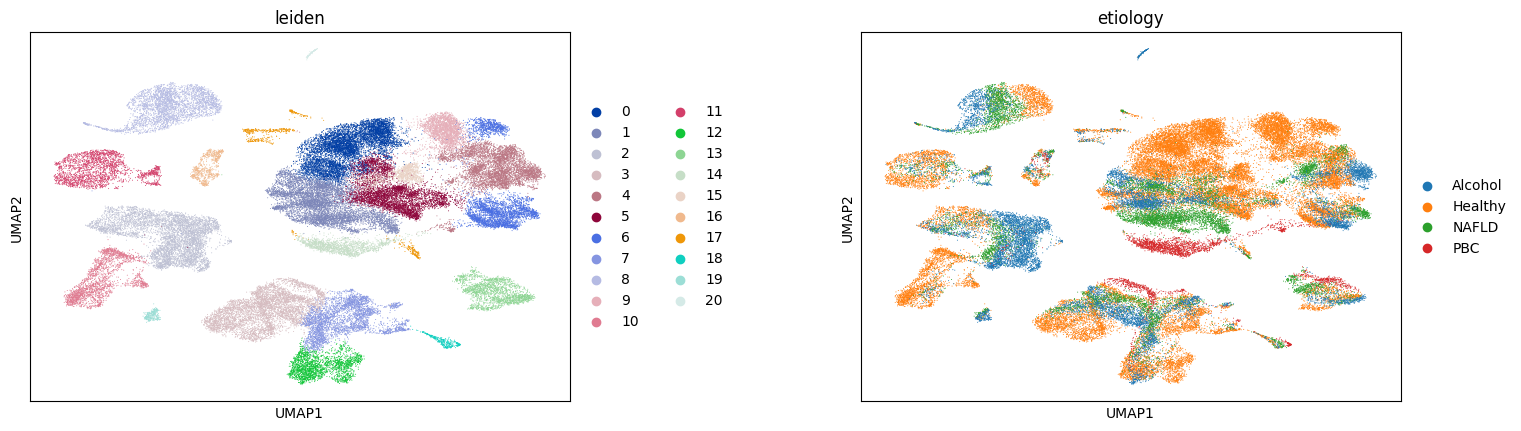

In [ ]:
# Neighbors, UMAP, and Leiden clustering
'''Build the graph structure used for visualization and clustering'''
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=0.4)
#sc.pl.umap(adata_hvg, color=["leiden", "etiology"], wspace=0.4, show=True)

adata_hvg.write(os.path.join(output_dir, "adata_hvg_umap_leiden.h5ad"))

PROGRAM-BASED HSC SELECTION

In [ ]:
'''This stage scores cells using a positive HSC signature and three exclusion programs (immune, endothelial, epithelial) to enrich for stellate cell candidates'''
# Prepare aligned object for module scoring
'''
Use the full-gene object for scoring whenever possible so that
Gene-set coverage is not reduced by HVG subsetting
'''
def keep_genes(adata_obj, genes):
    gs = []
    vset = set(adata_obj.var_names.astype(str))
    for g in genes:
        g2 = str(g)
        if g2 in vset:
            gs.append(g2)
    return gs

def ensure_obs_alignment(a_src, a_tgt):
    if not a_src.obs_names.equals(a_tgt.obs_names):
        a_src = a_src[a_tgt.obs_names, :].copy()
    return a_src

if "adata" in globals():
    adata_score = ensure_obs_alignment(adata, adata_hvg)
else:
    adata_score = adata_hvg.copy()

Present genes: {'HSC_CORE': 59, 'IMMUNE': 10, 'ENDO': 6, 'EPI': 8}


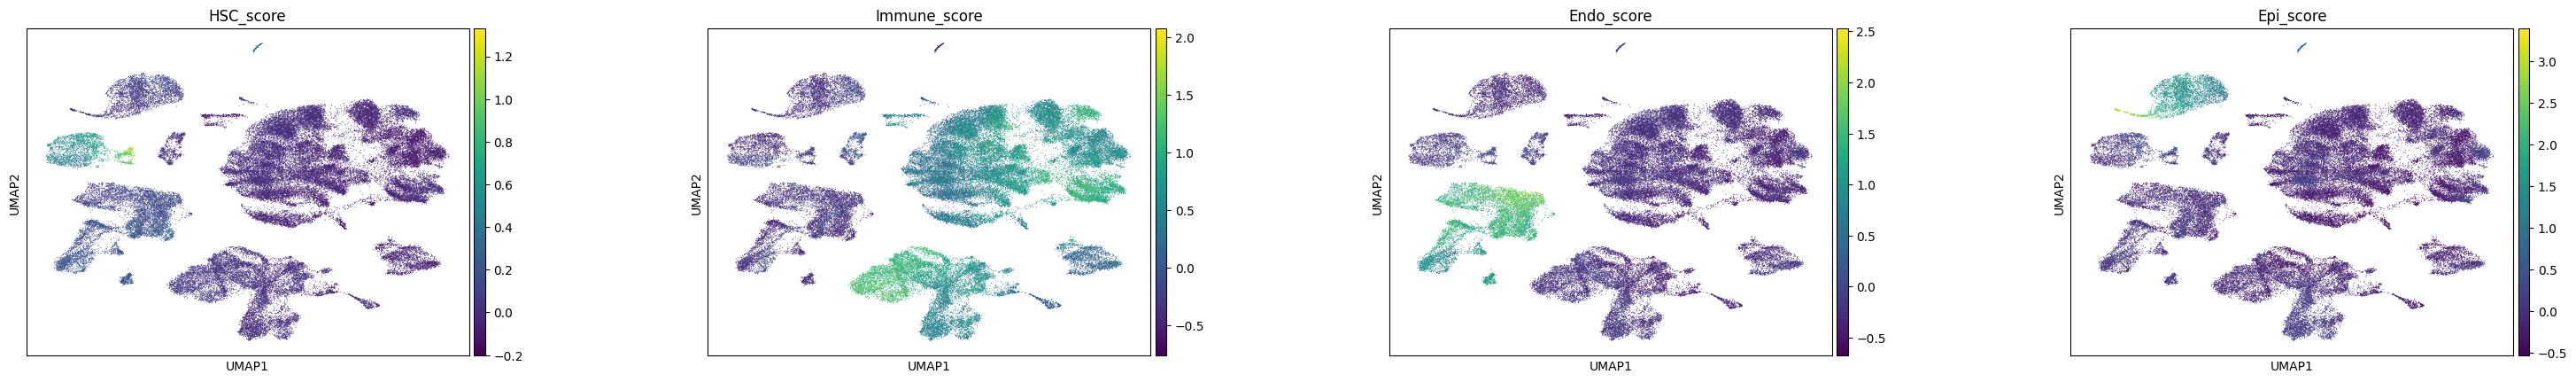

In [ ]:
# HSC / exclusion gene-program scoring
'''
Convert marker symbols to the correct gene IDs, then score:
- HSC core program
- immune exclusion program
- endothelial exclusion program
- epithelial exclusion program
'''
def keep_genes(adata, genes):
    if 'gene_symbol' not in adata.var.columns:
        raise KeyError("The 'gene_symbol' column is not found in adata.var. Please check your AnnData object.")

    symbol_to_id_map = adata.var.set_index('gene_symbol')['gene_id'].to_dict()

    present_gene_ids = []
    for symbol in genes:
        gene_id = symbol_to_id_map.get(symbol)
        if gene_id is not None and gene_id in adata.var_names:
            present_gene_ids.append(gene_id)
    return present_gene_ids

HSC_CORE = ["LRAT","RBP1","PDGFRB","DES","GFAP","DCN","LUM","COL1A1","COL1A2","COL3A1","RGS5",
            "RELN","PPARG","NGFR","CYGB","COLEC11","PPARA","FOXF1","IGFBP7","IGFBP6",
            "WT1","FGF10","MEG3","OLFML3","IGFBP3","SEMA7A","NR1H4","PDGFRA","CYR61",
            "VCL","SYP","MYB","AGTR1","HGF","ACTA2","TIMP1","SPARC","MYL9","CD36",
            "TAGLN","CTGF","BGN","TPM2","GFAP","FAP","AEBP1","ITGAV","LOXL2","SERPINE1","LTBP2",
            "CREM","CCL2","VEGFA","SLC8A1","GAS7","EFEMP1","SPON1","KLF9","S100A6"
]
IMMUNE   = ["PTPRC","LYZ","LST1","TYROBP","FCN1","CD3D","CD3E","MS4A1","NKG7","GNLY"]
ENDO     = ["PECAM1","VWF","KDR","RAMP2","GNG11","CLEC14A"]
EPI      = ["ALB","APOA1","APOC1","TTR","KRT8","KRT18","KRT19","EPCAM"]

#score genes
core = keep_genes(adata_score, HSC_CORE)
imm  = keep_genes(adata_score, IMMUNE)
endo = keep_genes(adata_score, ENDO)
epi  = keep_genes(adata_score, EPI)

print("Present genes:", {"HSC_CORE":len(core), "IMMUNE":len(imm), "ENDO":len(endo), "EPI":len(epi)})

if len(core) < 4:
    raise ValueError(f"Too few HSC_CORE genes present ({len(core)}). Check var_names or gene symbols.")
if len(imm) < 4:
    print("Warning: IMMUNE gene list is small; anti-score may be weaker.")
if len(endo) < 3:
    print("Warning: ENDO gene list is small; anti-score may be weaker.")
if len(epi) < 3:
    print("Warning: EPI gene list is small; anti-score may be weaker.")

sc.tl.score_genes(adata_score, core, score_name="HSC_score", use_raw=False)
sc.tl.score_genes(adata_score, imm,  score_name="Immune_score", use_raw=False)
sc.tl.score_genes(adata_score, endo, score_name="Endo_score", use_raw=False)
sc.tl.score_genes(adata_score, epi,  score_name="Epi_score", use_raw=False)

# Transfer scores back to the HVG object used for embedding/clustering
for c in ["HSC_score","Immune_score","Endo_score","Epi_score"]:
    adata_hvg.obs[c] = adata_score.obs[c].values

# sc.pl.umap(
#     adata_hvg,
#     color=["HSC_score","Immune_score","Endo_score","Epi_score"],
#     wspace=0.4,
#     show=True)

In [14]:
hsc_cells = adata_hvg.obs_names[adata_hvg.obs["is_HSC_candidate"]].tolist()

if "adata" in globals():
    adata_hsc = adata[hsc_cells, :].copy()
else:
    adata_hsc = adata_hvg[hsc_cells, :].copy()

adata_hsc.write(os.path.join(output_dir, "GSE136103_HSC_candidates.h5ad"))
adata_hsc

AnnData object with n_obs × n_vars = 8451 × 25296
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease_group', 'etiology', 'cd45_status', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'HSC_score', 'Immune_score', 'Endo_score', 'Epi_score'
    var: 'gene_id', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'etiology_colors', 'log1p', 'hvg'

RE_CLUSTER HEPATIC STELLATE CELL

In [ ]:
'''After enrichment, the HSC compartment is reprocessed independently to improve subtype resolution before functional state assignment'''
# Recompute HVGs, PCA, graph, and Leiden clusters within the HSC subset
sc.pp.highly_variable_genes(adata_hsc, n_top_genes=2000, flavor="seurat", subset=False)
sc.pp.scale(adata_hsc, max_value=10)
sc.tl.pca(adata_hsc, svd_solver="arpack", use_highly_variable=True)
sc.pp.neighbors(adata_hsc, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_hsc)
sc.tl.leiden(adata_hsc, resolution=0.5)
# sc.pl.umap(adata_hsc, color=["leiden", "etiology", "patient_id"], wspace=0.4, show=False)

# Convert variable names to gene symbols for easier downstream interpretation
if "gene_symbol" in adata_hsc.var.columns:
    adata_hsc.var["gene_symbol"] = adata_hsc.var["gene_symbol"].astype(str)
    adata_hsc.var_names = adata_hsc.var["gene_symbol"].values
    adata_hsc.var_names_make_unique()

def keep_genes(adata_obj, genes):
    gset = set(adata_obj.var_names.astype(str))
    return [g for g in genes if g in gset]
if "log1p" not in adata_hsc.uns:
    sc.pp.normalize_total(adata_hsc, target_sum=1e4)
    sc.pp.log1p(adata_hsc)

adata_hsc.raw = adata_hsc

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignor

/var/folders/lj/02z_qz8d0jv6_4l1bdd4xs400000gn/T/ipykernel_7546/967206727.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = adata_hsc.obs.groupby("leiden")[["Q_score","A1_score","A2_score","INF_score"]].mean()
/var/folders/lj/02z_qz8d0jv6_4l1bdd4xs400000gn/T/ipykernel_7546/967206727.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["etiology", "HSC_state"])


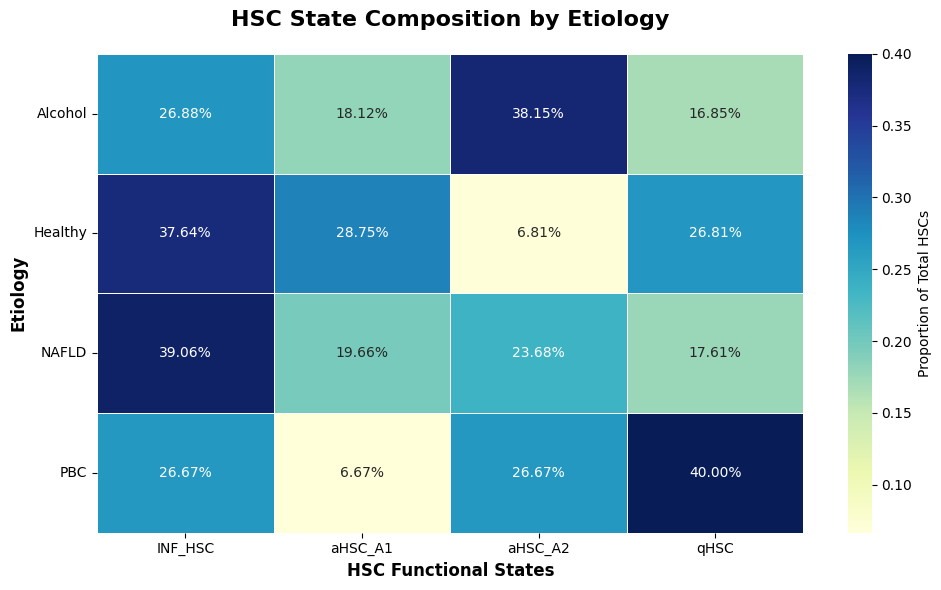

In [ ]:
# HSC functional state scoring and composition summary
'''Four state programs:
- qHSC: quiescent/homeostatic
- aHSC_A1: contractile / myofibroblast-like
- aHSC_A2: ECM-producing / fibrogenic
- INF_HSC: inflammatory'''

qHSC   = ["LRAT","RGS5","RELN","WT1","IGFBP3","RBP1","NR1H4","PPARG","COLEC11","CYGB","ADIRF","RARRES2"]   # quiescent
A1_HSC  = ["ACTA2","TAGLN","MYL9","TPM2","CNN1","CALD1","NGFR","PDGFRA","CYR61","IGFBP7","IGFBP6", "VCL","SYP","MYB","AGTR1","ADAMTS13","HGF","FGF10"]  # contractile / myofibroblast-like
A2_HSC  = ["DES", "GFAP","COL1A1","COL1A2","COL3A1","DCN","LUM","TIMP1","CTGF","SPARC", "MYL9","CTGF","TPM2","FAP","AEBP1","ITGAV","LOXL2","SERPINE1","LTBP2","S100A6"]  # ECM/fibrogenic
INF = ["CCL2","CXCL2","CXCL8","IL6","NFKBIA","TNFAIP3","ICAM1","CXCL1","CD36","CLEC11A","CREM","VEGFA","CYR61","SLC8A1","GAS7","EFEMP1","SPON1","KLF9"]  # inflammatory
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, qHSC),   score_name="Q_score",   use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, A1_HSC), score_name="A1_score",  use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, A2_HSC), score_name="A2_score",  use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, INF),score_name="INF_score", use_raw=True)

# Assign cluster-level dominant state
cluster_means = adata_hsc.obs.groupby("leiden")[["Q_score","A1_score","A2_score","INF_score"]].mean()
state_map = cluster_means.idxmax(axis=1).replace({
    "Q_score":"qHSC", "A1_score":"aHSC_A1", "A2_score":"aHSC_A2", "INF_score":"INF_HSC"
}).to_dict()

adata_hsc.obs["HSC_state"] = adata_hsc.obs["leiden"].map(state_map).astype("category")
# sc.pl.umap(adata_hsc, color=["Q_score","A1_score","A2_score","INF_score"], wspace=0.35, frameon=True, show=False)

score_cols = ["Q_score","A1_score","A2_score","INF_score"]
scores = adata_hsc.obs[score_cols].copy()
state = scores.idxmax(axis=1).replace({ "Q_score":"qHSC","A1_score":"aHSC_A1","A2_score":"aHSC_A2", "INF_score":"INF_HSC"})
adata_hsc.obs["HSC_state"] = state.astype("category")

# Summarize proportions of HSC functional states across etiologies.
assert adata_hsc.raw is not None, "adata_hsc.raw must contain log-normalized data"
state_counts = (
    adata_hsc.obs
    .groupby(["etiology", "HSC_state"])
    .size()
    .unstack(fill_value=0)
)
state_props = state_counts.div(state_counts.sum(axis=1), axis=0)
import seaborn as sns
plt.figure(figsize=(10, 6))
ax = sns.heatmap(state_props, annot=True, fmt=".2%", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Proportion of Total HSCs'})
plt.title("HSC State Composition by Etiology", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("HSC Functional States", fontsize=12, fontweight='bold')
plt.ylabel("Etiology", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()